# Run a forward model simulation of Mars using archNEMESIS

In this notebook, we show how the users can use the functionality within texespy and the archNEMESIS radiative transfer algorithm to run forward model simulations of TEXES observations of Mars. 

The functionality implemented here is meant to be used as the baseline for forward models, but using these for retrievals would require a few refinements (e.g., telluric transmission at the exact date and time of the observations, refinement of Mars reference atmosphere, etc.).

In [5]:
import texespy as texes
import matplotlib.pyplot as plt
import numpy as np
import archnemesis as ans
import h5py

## 1. Inputs

Here, we need to select a few inputs to specify the observational setup we want to simulate.

In [2]:
#INPUTS
#################################################################################################################

#Spectral characteristics
filename = "mars_example"   #Name of the simulation
waven_min = 1350.           #Minimum wavenumber (cm-1)
waven_max = 1355.           #Maximum wavenumber (cm-1)
resolving_power = 90000.    #Resolving power of TEXES
delv = 0.001                #Wavenumber step at which to calculate the absorption cross sections (cm-1)

#Radiatively active gases to include (apart from CO2 and H2O which are there by default)
id_gases = [8]             #archNEMESIS Gas ID
iso_gases = [0]            #archNEMESIS isotopologue ID
vmr_gases = [5.0e-9]       #VMR of the gas

#Atmospheric aerosols
tau_dust = 0.1             #Visible dust column optical depth
tau_ice = 0.05             #Visible water ice column optical depth

#Geometry parameters
v_doppler = 0.
emiss_ang = 0.
sol_ang = 0.
azi_ang = 0.

#Telluric contamination
include_telluric = True
emiss_ang_earth = 180.          #(90 < emiss_ang_earth < 180) 180 means looking straight at zenith -

## 2. Running simulation

In [3]:
vconv, telluric_transmission, mars_spectrum, gasnames, mars_gas = \
    texes.archnemesis.mars.perform_analysis(filename,
                                            waven_min,waven_max,delv,
                                            tau_dust=tau_dust, tau_ice=tau_ice,
                                            resolving_power=resolving_power,v_doppler=v_doppler,
                                            emiss_ang=emiss_ang,sol_ang=sol_ang,azi_ang=azi_ang,
                                            id_gases=id_gases,iso_gases=iso_gases,vmr_gases=vmr_gases,
                                            hitran_file=texes.paths.archnemesis_hitran24,
                                            split_gas_contributions=True,
                                            include_telluric=include_telluric,emiss_ang_earth=emiss_ang_earth)

Creating archNEMESIS file
Calculating Mode 1 - Dust


INFO :: makephase :: Scatter_0.py-1348 :: Normalisation of phase function should be 1.0
INFO :: makephase :: Scatter_0.py-1349 :: Minimum integral of phase function is 1.0000091044599289
INFO :: makephase :: Scatter_0.py-1350 :: Maximum integral of phase function is 1.000009162989274
INFO :: makephase :: Scatter_0.py-1348 :: Normalisation of phase function should be 1.0
INFO :: makephase :: Scatter_0.py-1349 :: Minimum integral of phase function is 1.000061197807368
INFO :: makephase :: Scatter_0.py-1350 :: Maximum integral of phase function is 1.0000617620088539


Calculating Mode 2 - Water ice


INFO :: read_apr :: Variables_0.py-823 :: 
Variables_0 :: read_apr :: varident [2 0 2]. Constructed model "Model2" (id=2)
INFO :: read_apr :: Variables_0.py-826 ::   Model2:
  |- id : 2
  |- parent classes: PreRTModelBase
  |- description: In this model, the atmospheric parameters are scaled using a
  |               single factor with  respect to the vertical profiles in the
  |               reference atmosphere
  |- n_state_vector_entries : 1
  |- state_vector_slice : slice(0, 1, None)
  |- state_vector_start : 0
  |- target : 0
  |- Parameters:
  |  |- scaling_factor :
  |  |  |- slice : slice(0, 1, None)
  |  |  |- unit : PROFILE_TYPE
  |  |  |- description: Scaling factor applied to the reference profile
  |  |  |- apriori value : 1.0
INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1472 :: RUNTIME calculation is loading desired wavenumber range from databases
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table se

grp.file.filename='mars_example.h5'
ciatable_h5_path='/home/alday/Documents/Projects/archnemesis-dist/archnemesis/Data/cia/CO2-CO2_HITRAN.h5'
Reading archNEMESIS file
Calculating telluric contamination


INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/srv/workspace/data/nemesis/spectroscopy/linedata/hitran24/hitran24.h5' wavemin=np.float64(1349.9729246990353) wavemax=np.float64(1355.028319745394)
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/srv/workspace/data/nemesis/spectroscopy/linedata/hitran24/hitran24.h5' wavemin=np.float64(1349.9729246990353) wavemax=np.float64(1355.028319745394)
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/srv/workspace/data/nemesis/spectroscopy/linedata/hitran24/hitran24.h5' wavemin=np.float64(1349.9729246990353) wavemax=np.float64(1355.028319745394)
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/srv/workspace/data/nemesis/spectroscopy/linedata/hitran24/hitran24.h5' wavemin=np.float64(1349.9729246990353) wavemax=np.float64(1355.028319745394)
INFO :: __init__ :: ForwardModel_0.py-297 :: Checking at

Calculating Mars spectrum


INFO :: calc_klbl_online :: Spectroscopy_0.py-2114 :: Gas 2, Isotope 0 - Calculating line-by-line cross sections at runtime...
INFO :: calc_klbl_online :: Spectroscopy_0.py-2114 :: Gas 8, Isotope 0 - Calculating line-by-line cross sections at runtime...
INFO :: calculate_vertical_cia_opacity :: ForwardModel_0.py-3899 :: Calculating self.CIAX opacity
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3968 :: CIRSrad :: Aerosol optical depths at  (np.float64(1349.924), ' :: ', array([1.72443622e-10, 1.46114487e-08]))
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3986 :: Calculating TOTAL opacity
INFO :: calculate_layer_opacity :: ForwardModel_0.py-4003 :: CIRSradg :: Calculating TOTAL line-of-sight opacity
INFO :: CIRSrad :: ForwardModel_0.py-4468 :: CIRSrad :: IMODM = <PathCalcEnum.THERMAL_EMISSION: 64>
INFO :: calculate_thermal_emission_spectrum :: ForwardModel_0.py-4147 :: CIRSradg :: Calculating THERMAL_EMISSION
INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables

Calculating gas contributions


INFO :: calculate_vertical_cia_opacity :: ForwardModel_0.py-3899 :: Calculating self.CIAX opacity
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3968 :: CIRSrad :: Aerosol optical depths at  (np.float64(1349.924), ' :: ', array([1.72443622e-10, 1.46114487e-08]))
INFO :: calculate_layer_opacity :: ForwardModel_0.py-3986 :: Calculating TOTAL opacity
INFO :: calculate_layer_opacity :: ForwardModel_0.py-4003 :: CIRSradg :: Calculating TOTAL line-of-sight opacity
INFO :: CIRSrad :: ForwardModel_0.py-4468 :: CIRSrad :: IMODM = <PathCalcEnum.THERMAL_EMISSION: 64>
INFO :: calculate_thermal_emission_spectrum :: ForwardModel_0.py-4147 :: CIRSradg :: Calculating THERMAL_EMISSION
INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1472 :: RUNTIME calculation is loading desired wavenumber range from databases
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/srv/workspace/data/nemesis/spectroscopy/lined

## 3. Writing output file

Write the output parameters into a file just to save them 

In [6]:
#Write all these into HDF5 file so that we do not need to run it all the time
with h5py.File(filename+'_outputs.h5','w') as f:

    dset = f.create_dataset("wave", data=vconv)
    dset.attrs["units"] = "cm-1"
    dset.attrs["description"] = "Wavenumber array"

    dset = f.create_dataset("telluric_transmission", data=telluric_transmission)
    dset.attrs["units"] = ""
    dset.attrs["description"] = "Telluric transmission"

    dset = f.create_dataset("spectrum", data=mars_spectrum)
    dset.attrs["units"] = "erg s-1 cm-2 sr-1 (cm-1)-1"
    dset.attrs["description"] = "Radiance from Mars with all gas contributions"

    dset = f.create_dataset("gas_spectrum", data=mars_gas)
    dset.attrs["units"] = "erg s-1 cm-2 sr-1 (cm-1)-1"
    dset.attrs["description"] = "Radiance from Mars with each gas contribution individually"

    dt = h5py.string_dtype(encoding="utf-8")
    f.create_dataset("species", data=gasnames, dtype=dt)

## 4. Plotting the results

In [7]:
#Reading the file again
f = h5py.File(filename+'_outputs.h5', 'r')
waven = np.array(f['wave'])
spectot = np.array(f['spectrum'])
specgas = np.array(f['gas_spectrum'])
trans = np.array(f['telluric_transmission'])
gasnames = f["species"].asstr()[:]
f.close()

In [8]:
#estimating a baseline to use to plot the gas contributions
wavenx = np.array([waven[0],waven[-1]])
baselinex = np.array([specgas[0,-1],specgas[-1,-1]])

coeff = np.polyfit(wavenx, baselinex, 1)
baseline = np.polyval(coeff,waven)

#### Plotting the planetary and telluric spectra

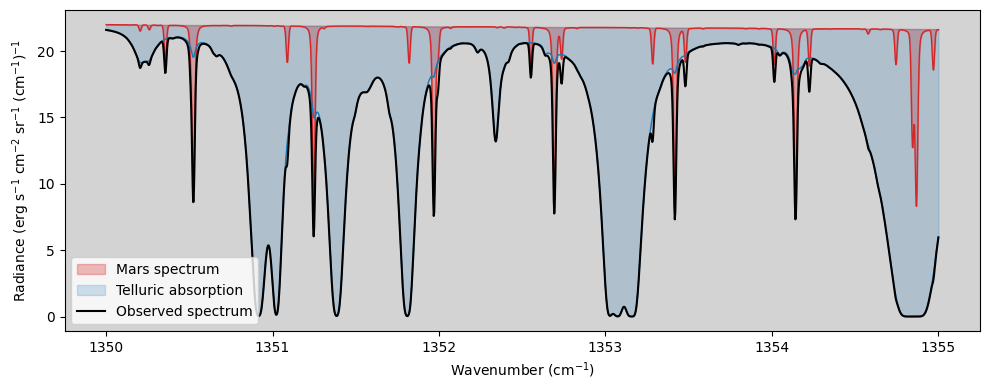

In [10]:
fig,ax1 = plt.subplots(1,1,figsize=(10,4))

ax1.fill_between(waven,spectot,baseline,alpha=0.3,color="tab:red",label="Mars spectrum")
ax1.plot(waven,spectot,linewidth=1.,c="tab:red")

cearth = "tab:blue"
ax1.fill_between(waven,baseline*trans,baseline,alpha=0.2,color=cearth,label="Telluric absorption")
ax1.plot(waven,baseline*trans,c=cearth,linewidth=1.)


ax1.plot(waven,spectot*trans,c="black",linewidth=1.5,label="Observed spectrum")

ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Radiance (erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$")
ax1.legend(loc="lower left")
ax1.set_facecolor("lightgray")
plt.tight_layout()

#### Plotting the contribution from different gases

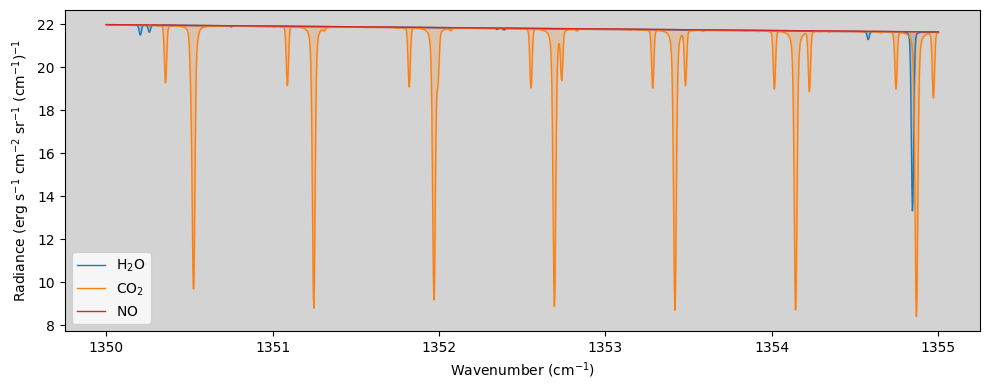

In [18]:
fig,ax1 = plt.subplots(1,1,figsize=(10,4))

colors = ["tab:blue","tab:orange","tab:red"]
for igas in range(specgas.shape[1]):
    gasnamex = '$'+ans.Data.gas_data.molecule_to_latex(gasnames[igas])+'$'
    ax1.fill_between(waven,specgas[:,igas],baseline,alpha=0.2,color=colors[igas])
    ax1.plot(waven,specgas[:,igas],c=colors[igas],linewidth=1.,label=gasnamex)

#ax1.plot(waven,spectot,label="Total",linewidth=1.,c="black")

ax1.legend(loc="lower left")

ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Radiance (erg s$^{-1}$ cm$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$")
ax1.set_facecolor("lightgray")
plt.tight_layout()